#  Resume Dataset — Keşifsel Veri Analizi (EDA)

**Kaynak:** [Kaggle — Resume Dataset](https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset)  
**Amaç:** Ham CSV verisini analiz ederek sektörel dağılım, deneyim, eğitim ve metin özellikleri hakkında kapsamlı görsel içgörüler üretmek.

---
###  İçindekiler
1. [Kütüphaneler & Veri Yükleme](#1)
2. [Veri Ön İşleme & Özellik Mühendisliği](#2)
3. [Genel Veri Özeti](#3)
4. [Kategori Dağılımı](#4)
5. [Deneyim Analizi](#5)
6. [Eğitim Seviyesi Analizi](#6)
7. [Metin & Uzunluk Analizi](#7)
8. [Kelime Bulutu & Frekans Analizi](#8)
9. [Kategori × Deneyim İlişkisi](#9)
10. [Korelasyon & Özet Dashboard](#10)

---
## 1. Kütüphaneler & Veri Yükleme <a id='1'></a>

In [38]:
# ── Standart kütüphaneler ──────────────────────────────────────────────────────
import re
import warnings
from collections import Counter

# ── Veri işleme ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Görselleştirme ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# ── Global tema ───────────────────────────────────────────────────────────────
PALETTE      = 'viridis'
BG_COLOR     = '#F8F9FA'
ACCENT       = '#2C3E50'
HIGHLIGHT    = '#E74C3C'
FONT_TITLE   = {'fontsize': 16, 'fontweight': 'bold', 'color': ACCENT}
FONT_LABEL   = {'fontsize': 12, 'color': '#555555'}

plt.rcParams.update({
    'figure.facecolor' : BG_COLOR,
    'axes.facecolor'   : BG_COLOR,
    'axes.edgecolor'   : '#CCCCCC',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'grid.color'       : '#E0E0E0',
    'grid.linestyle'   : '--',
    'font.family'      : 'DejaVu Sans',
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
})

# ── Veri yükle ────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/raw/resume.csv')

print(f' Veri yüklendi  →  {df.shape[0]:,} satır  |  {df.shape[1]} sütun')
df.head(3)

 Veri yüklendi  →  2,484 satır  |  4 sütun


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


---
## 2. Veri Ön İşleme & Özellik Mühendisliği <a id='2'></a>

In [39]:
# ── Deneyim yılı çıkarımı ─────────────────────────────────────────────────────
def extract_experience(text: str) -> float | None:
    """Serbest metinden deneyim yılını regex ile çeker.
    '10+ years', '5 yrs', '8 year of experience' gibi kalıpları destekler.
    50 yıldan büyük değerleri aykırı veri (outlier) kabul eder.
    """
    pattern = r'(\d+)\+?\s*(?:years?|yrs?|experience|exp)'
    match = re.search(pattern, str(text).lower())
    if match:
        val = int(match.group(1))
        return float(val) if val < 50 else None
    return None


# ── Eğitim seviyesi sınıflandırması ──────────────────────────────────────────
def classify_education(text: str) -> str:
    """Hiyerarşik sırayla (PhD → Master → Bachelor → Other) eğitim seviyesini belirler."""
    text = str(text).lower()
    if any(k in text for k in ['phd', 'doctorate', 'ph.d', 'dr.']):
        return 'PhD'
    if any(k in text for k in ['master', 'msc', 'mba', 'ms ', 'ma ', 'postgraduate', 'm.s', 'm.b']):
        return "Master's"
    if any(k in text for k in ['bachelor', 'bs ', 'ba ', 'undergraduate', 'b.s', 'b.a', 'degree', 'university', 'college']):
        return "Bachelor's"
    return 'Belirtilmemiş'


# ── Temel metin özellikleri ────────────────────────────────────────────────────
df['experience']       = df['Resume_str'].apply(extract_experience)
df['education_level']  = df['Resume_str'].apply(classify_education)
df['word_count']       = df['Resume_str'].apply(lambda x: len(str(x).split()))
df['char_count']       = df['Resume_str'].apply(lambda x: len(str(x)))
df['sentence_count']   = df['Resume_str'].apply(lambda x: len(re.split(r'[.!?]+', str(x))))
df['avg_word_length']  = df['Resume_str'].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
)
df['has_email']        = df['Resume_str'].str.contains(r'[\w.+-]+@[\w-]+\.[\w.]+', regex=True)
df['has_linkedin']     = df['Resume_str'].str.lower().str.contains('linkedin', na=False)
df['has_github']       = df['Resume_str'].str.lower().str.contains('github', na=False)

print(' Özellik mühendisliği tamamlandı.')
print(f"   • Deneyim verisi bulunanlar : {df['experience'].notna().sum():,} ({df['experience'].notna().mean():.1%})")
print(f"   • Eğitim seviyesi dağılımı  : {dict(df['education_level'].value_counts())}")
df[['word_count', 'char_count', 'sentence_count', 'avg_word_length', 'experience']].describe().round(2)

 Özellik mühendisliği tamamlandı.
   • Deneyim verisi bulunanlar : 951 (38.3%)
   • Eğitim seviyesi dağılımı  : {"Master's": 2230, "Bachelor's": 162, 'PhD': 76, 'Belirtilmemiş': 16}


,word_count,char_count,sentence_count,avg_word_length,experience
count,2484.00,2484.00,2484.00,2484.00,951.00
mean,811.33,6295.31,40.40,6.30,11.74
std,371.01,2769.25,26.23,0.39,8.16
min,0.00,21.00,1.00,0.00,0.00
25%,651.00,5160.00,23.75,6.11,5.00
50%,757.00,5886.50,38.00,6.33,10.00
75%,933.00,7227.25,51.00,6.55,16.00
max,5190.00,38842.00,408.00,7.55,45.00


---
## 3. Genel Veri Özeti <a id='3'></a>

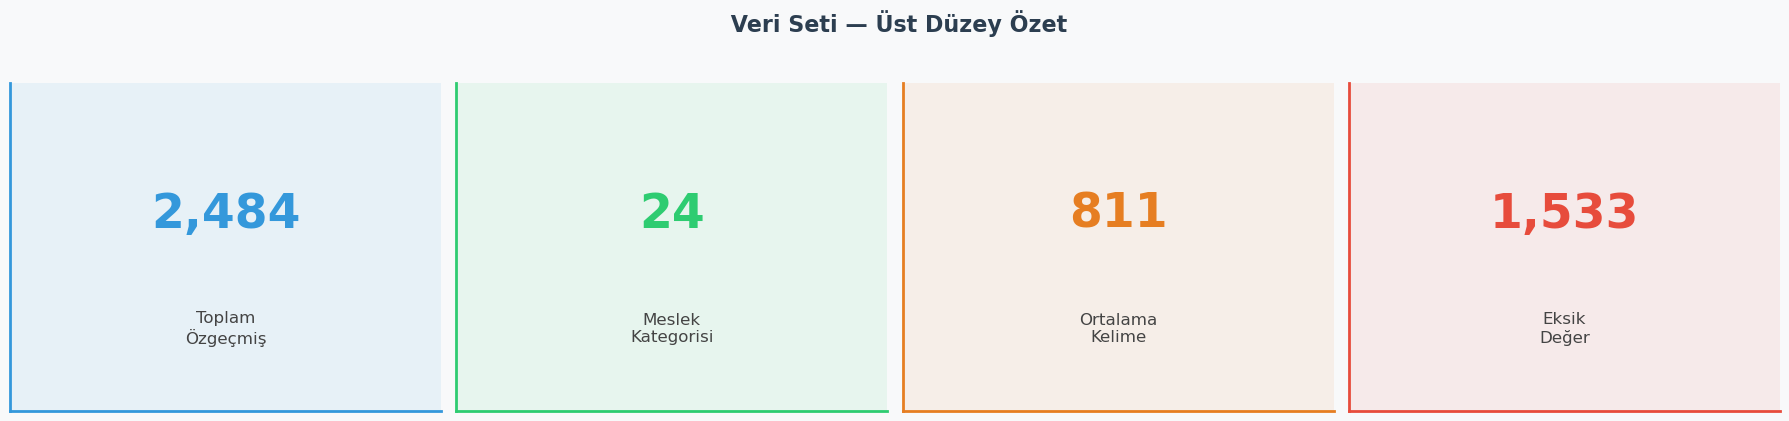

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(' Veri Seti — Üst Düzey Özet', **FONT_TITLE, y=1.04)
fig.patch.set_facecolor(BG_COLOR)

kpi = [
    ('Toplam\nÖzgeçmiş',     f"{len(df):,}",                   '#3498DB'),
    ('Meslek\nKategorisi',   str(df['Category'].nunique()),     '#2ECC71'),
    ('Ortalama\nKelime',     f"{df['word_count'].mean():.0f}", '#E67E22'),
    ('Eksik\nDeğer',         f"{df.isnull().sum().sum():,}",   '#E74C3C'),
]

for ax, (label, value, color) in zip(axes, kpi):
    ax.set_facecolor(color + '15')
    ax.text(0.5, 0.60, value, ha='center', va='center', fontsize=34,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=12,
            color='#444444', transform=ax.transAxes, multialignment='center')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('../visuals/00_kpi_summary.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 4. Kategori Dağılımı <a id='4'></a>

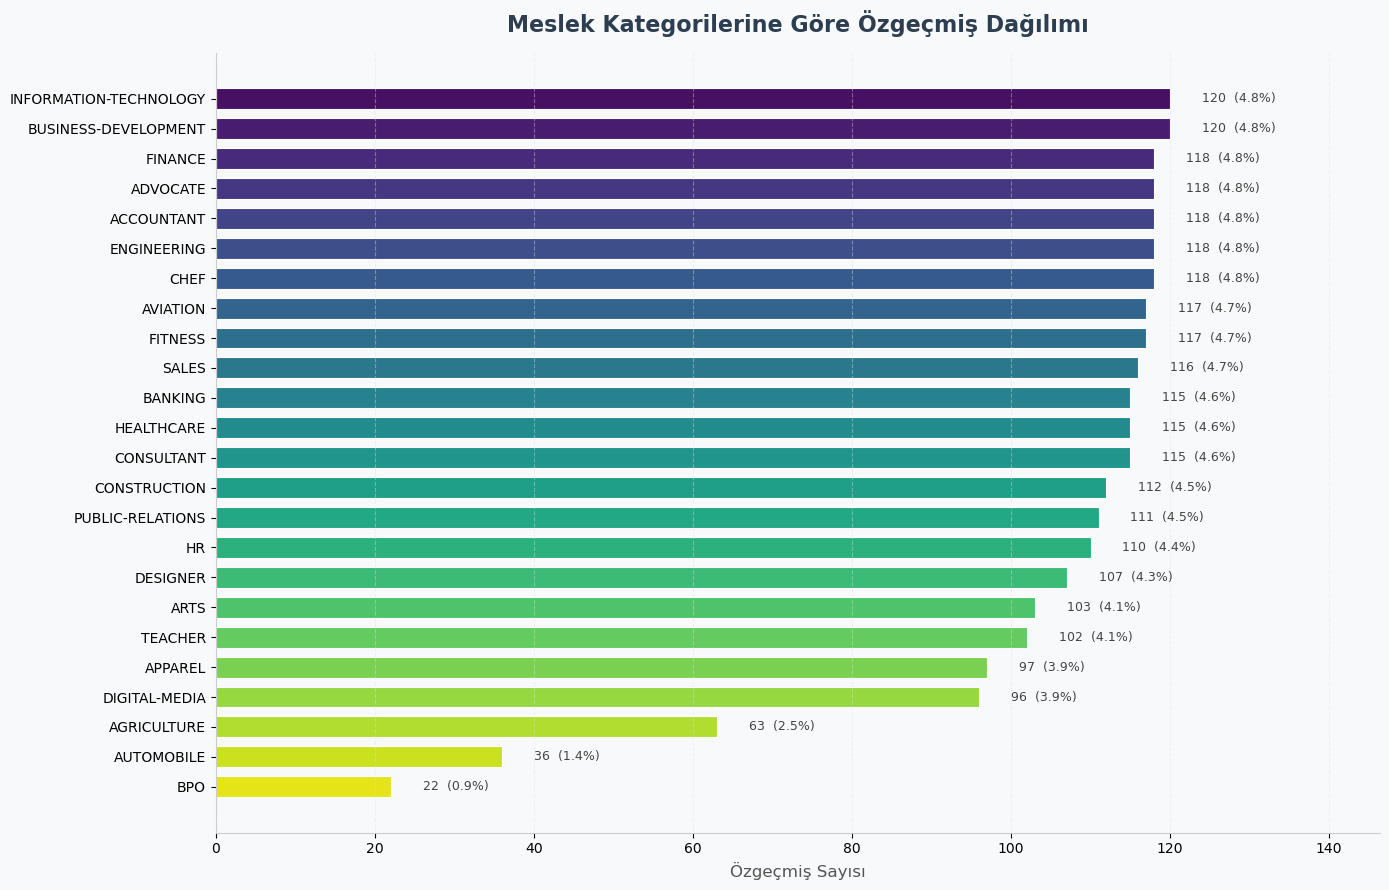

In [23]:
cat_counts = df['Category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Count']
cat_counts['Percentage'] = (cat_counts['Count'] / len(df) * 100).round(1)

colors = sns.color_palette(PALETTE, n_colors=len(cat_counts))

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(BG_COLOR)

bars = ax.barh(
    cat_counts['Category'],
    cat_counts['Count'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.7,
)

# Değer etiketleri
for bar, pct in zip(bars, cat_counts['Percentage']):
    ax.text(
        bar.get_width() + 4,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.0f}  ({pct}%)',
        va='center', ha='left', fontsize=9, color='#444'
    )

ax.set_title('Meslek Kategorilerine Göre Özgeçmiş Dağılımı', **FONT_TITLE, pad=15)
ax.set_xlabel('Özgeçmiş Sayısı', **FONT_LABEL)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(0, cat_counts['Count'].max() * 1.22)
ax.grid(axis='x', alpha=0.4)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../visuals/01_kategori_dagilimi.png', dpi=200, bbox_inches='tight')
plt.show()

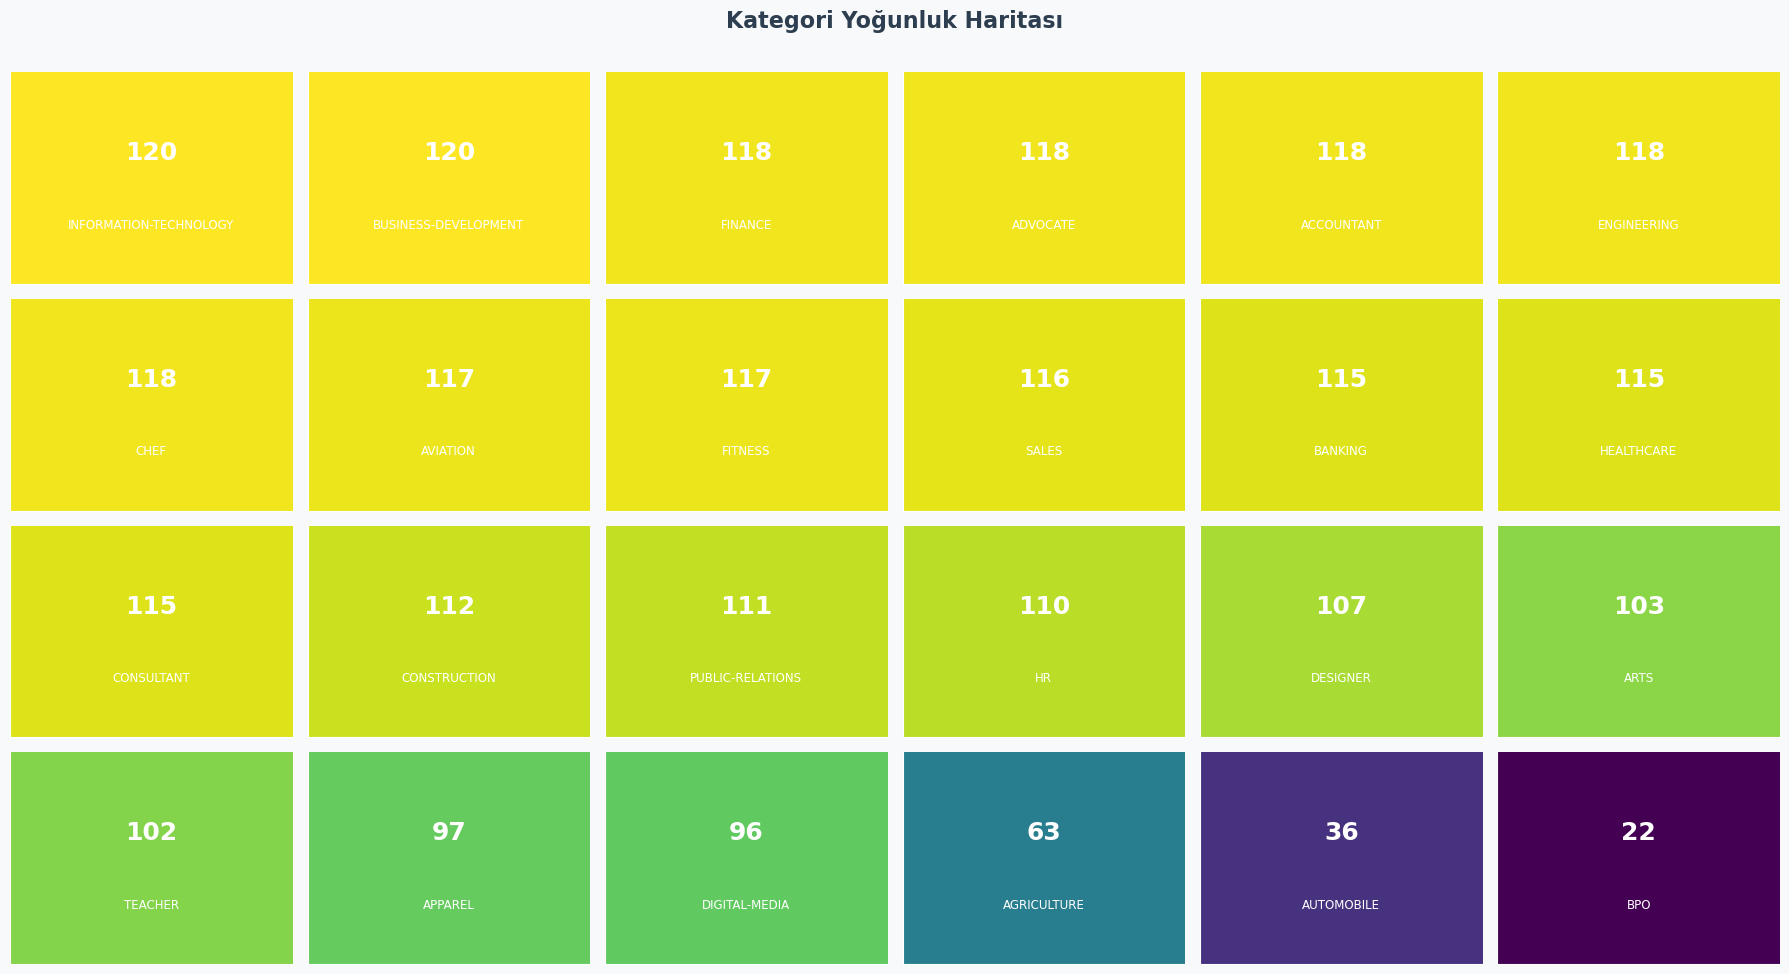

In [ ]:
# ── Kategorileri normalize edilmiş ısı haritası olarak göster ─
import math

n_cats  = len(cat_counts)
n_cols  = 6
n_rows  = math.ceil(n_cats / n_cols)
norm    = plt.Normalize(cat_counts['Count'].min(), cat_counts['Count'].max())
cmap    = plt.colormaps[PALETTE]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 2.4))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Kategori Yoğunluk Haritası', **FONT_TITLE, y=1.01)
axes_flat = axes.flatten()

for i, (_, row) in enumerate(cat_counts.iterrows()):
    ax   = axes_flat[i]
    rgba = cmap(norm(row['Count']))
    ax.set_facecolor(rgba)
    ax.text(0.5, 0.62, str(int(row['Count'])), ha='center', va='center',
            fontsize=18, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.28, row['Category'], ha='center', va='center',
            fontsize=8.5, color='white', transform=ax.transAxes, wrap=True,
            multialignment='center')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# Boş kareleri gizle
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/02_kategori_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 5. Deneyim Analizi <a id='5'></a>

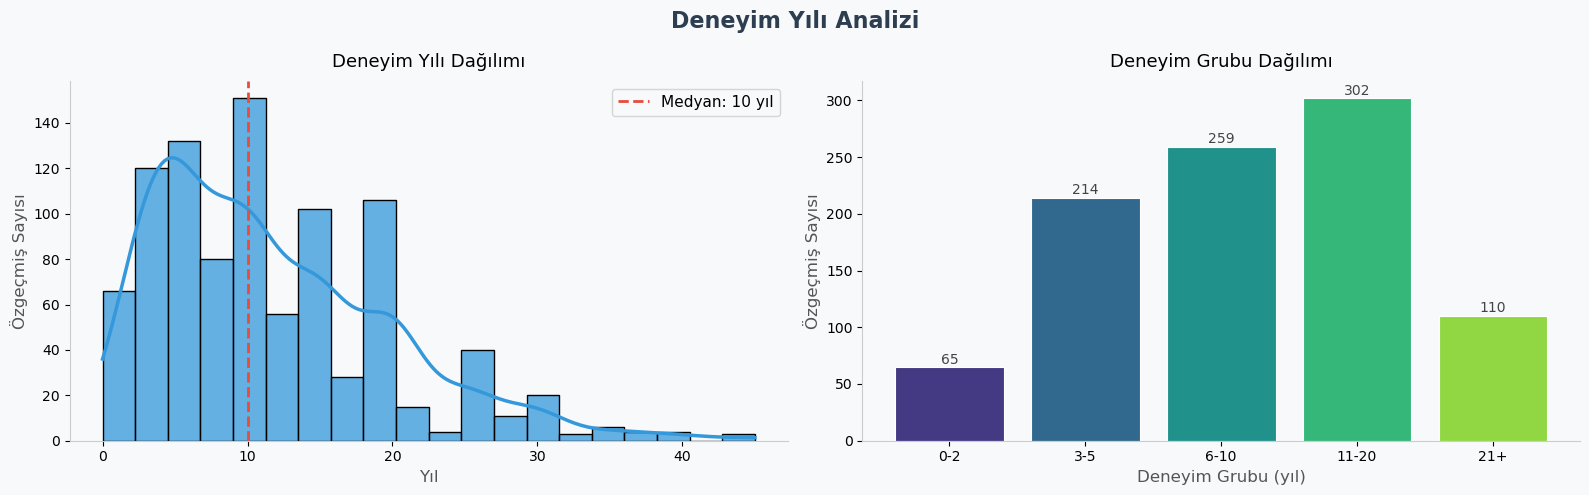

Deneyim verisi bulunan özgeçmişler: 951 / 2,484
count    951.00
mean      11.74
std        8.16
min        0.00
25%        5.00
50%       10.00
75%       16.00
max       45.00
Name: experience, dtype: float64


In [42]:
exp_df = df.dropna(subset=['experience'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Deneyim Yılı Analizi', **FONT_TITLE)

# ── Histogram + KDE ──────────────────────────────────────────────────────────
sns.histplot(exp_df['experience'], bins=20, kde=True, ax=ax1,
             color='#3498DB', alpha=0.75, line_kws={'lw': 2.5, 'color': ACCENT})
med = exp_df['experience'].median()
ax1.axvline(med, color=HIGHLIGHT, lw=2, linestyle='--', label=f'Medyan: {med:.0f} yıl')
ax1.set_title('Deneyim Yılı Dağılımı', fontsize=13, pad=10)
ax1.set_xlabel('Yıl', **FONT_LABEL)
ax1.set_ylabel('Özgeçmiş Sayısı', **FONT_LABEL)
ax1.legend(fontsize=11)

# ── Kutu grafiği (deneyim grubu) ─────────────────────────────────────────────
bins_exp   = [0, 2, 5, 10, 20, 50]
labels_exp = ['0-2', '3-5', '6-10', '11-20', '21+']
exp_df = exp_df.copy()
exp_df['exp_group'] = pd.cut(exp_df['experience'], bins=bins_exp, labels=labels_exp, right=True)

group_counts = exp_df['exp_group'].value_counts().sort_index()
palette_grp  = sns.color_palette(PALETTE, n_colors=len(group_counts))
bars2 = ax2.bar(group_counts.index, group_counts.values, color=palette_grp,
                edgecolor='white', linewidth=0.8)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             str(int(bar.get_height())), ha='center', fontsize=10, color='#444')
ax2.set_title('Deneyim Grubu Dağılımı', fontsize=13, pad=10)
ax2.set_xlabel('Deneyim Grubu (yıl)', **FONT_LABEL)
ax2.set_ylabel('Özgeçmiş Sayısı', **FONT_LABEL)

plt.tight_layout()
plt.savefig('../visuals/03_deneyim_analizi.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Deneyim verisi bulunan özgeçmişler: {len(exp_df):,} / {len(df):,}")
print(exp_df['experience'].describe().round(2))

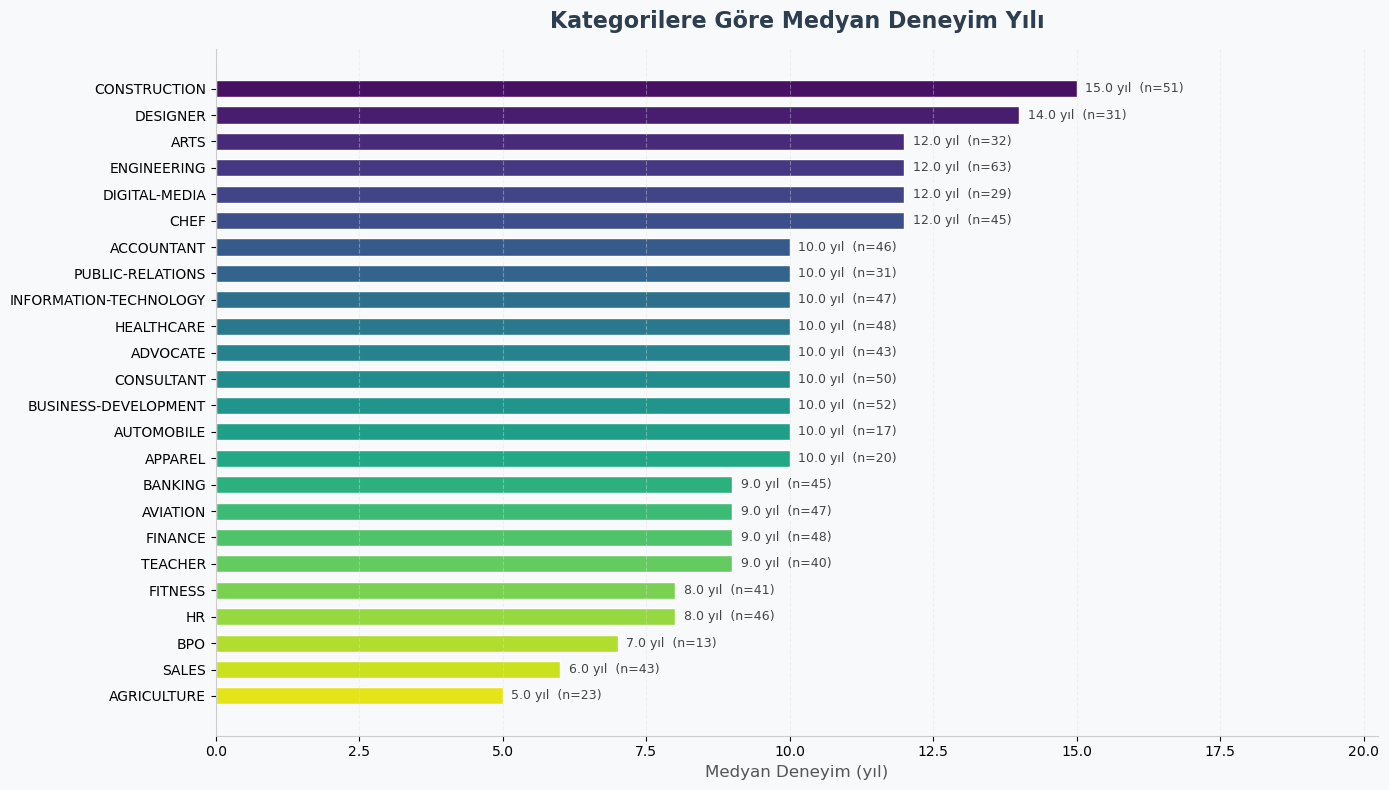

In [26]:
# ── Kategorilere göre medyan deneyim ─────────────────────────────────────────
med_exp = (
    exp_df.groupby('Category')['experience']
    .agg(['median', 'count', 'std'])
    .reset_index()
    .sort_values('median', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(BG_COLOR)

colors_med = sns.color_palette(PALETTE, n_colors=len(med_exp))
bars = ax.barh(med_exp['Category'], med_exp['median'], color=colors_med,
               edgecolor='white', height=0.65)

for bar, (_, row) in zip(bars, med_exp.iterrows()):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{row['median']:.1f} yıl  (n={int(row['count'])})",
            va='center', fontsize=9, color='#444')

ax.set_title('Kategorilere Göre Medyan Deneyim Yılı', **FONT_TITLE, pad=15)
ax.set_xlabel('Medyan Deneyim (yıl)', **FONT_LABEL)
ax.set_xlim(0, med_exp['median'].max() * 1.35)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('../visuals/04_kategori_deneyim.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 6. Eğitim Seviyesi Analizi <a id='6'></a>

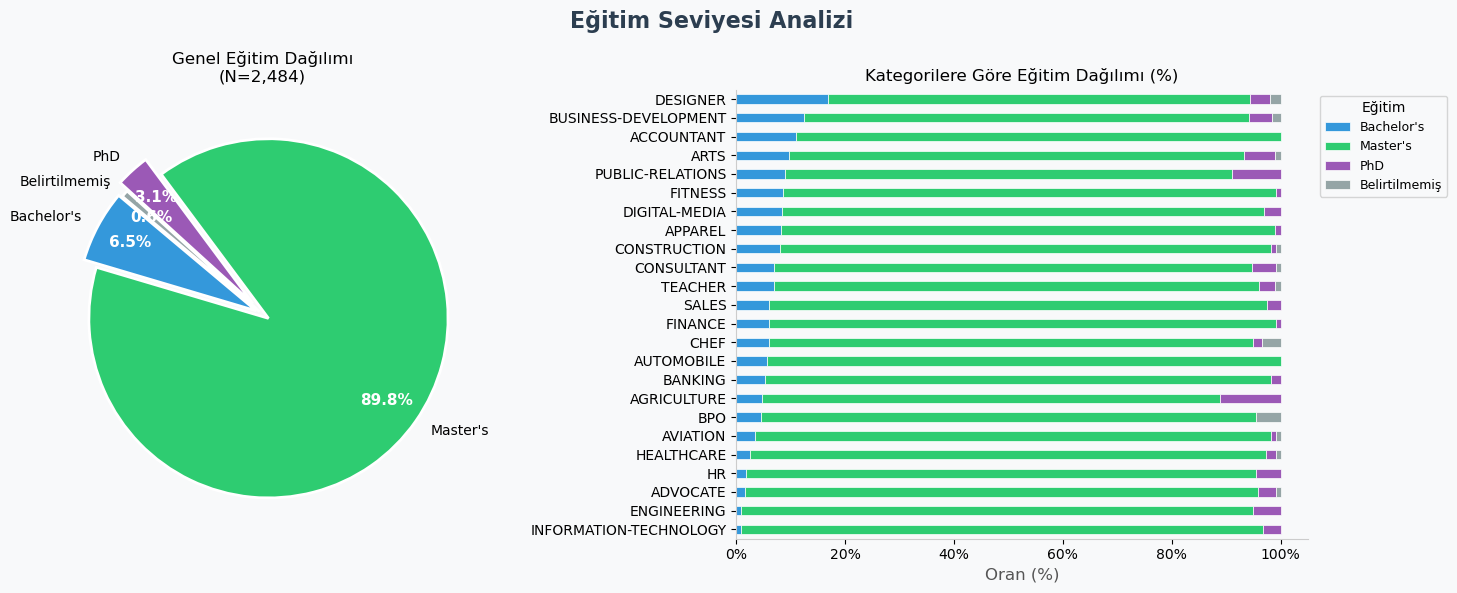

In [27]:
edu_order  = ["Bachelor's", "Master's", 'PhD', 'Belirtilmemiş']
edu_counts = df['education_level'].value_counts().reindex(edu_order).fillna(0)
edu_colors = ['#3498DB', '#2ECC71', '#9B59B6', '#95A5A6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Eğitim Seviyesi Analizi', **FONT_TITLE)

# ── Pasta grafiği ─────────────────────────────────────────────────────────────
wedges, texts, autotexts = ax1.pie(
    edu_counts,
    labels=edu_counts.index,
    autopct='%1.1f%%',
    colors=edu_colors,
    explode=[0.04, 0.04, 0.08, 0.02],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.80,
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
    t.set_color('white')
ax1.set_title(f'Genel Eğitim Dağılımı\n(N={len(df):,})', fontsize=12)

# ── Kategorilere göre eğitim dağılımı (stacked bar) ─────────────────────────
edu_cat = (
    df.groupby(['Category', 'education_level'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=edu_order, fill_value=0)
)
edu_cat_pct = edu_cat.div(edu_cat.sum(axis=1), axis=0) * 100
# En fazla Bachelor olan kategorilere göre sırala
edu_cat_pct = edu_cat_pct.sort_values("Bachelor's", ascending=True)

edu_cat_pct.plot(
    kind='barh', stacked=True, ax=ax2,
    color=edu_colors, edgecolor='white', linewidth=0.5,
)
ax2.set_title('Kategorilere Göre Eğitim Dağılımı (%)', fontsize=12)
ax2.set_xlabel('Oran (%)', **FONT_LABEL)
ax2.set_ylabel('')
ax2.legend(title='Eğitim', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../visuals/05_egitim_analizi.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 7. Metin & Uzunluk Analizi <a id='7'></a>

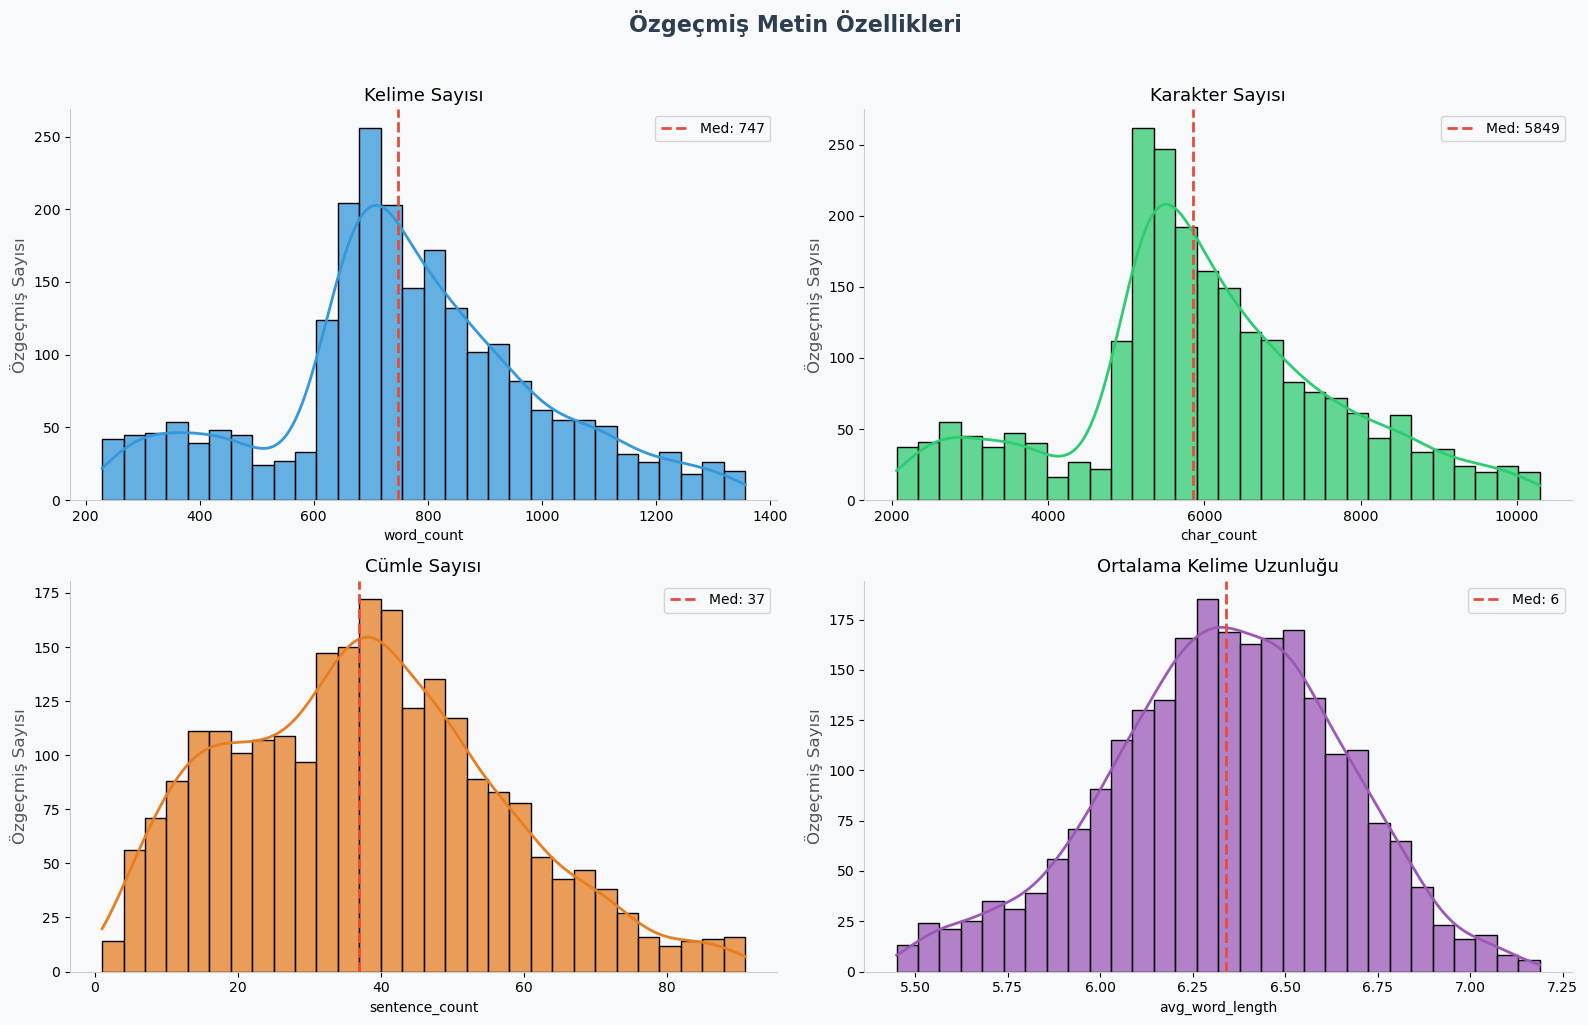

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Özgeçmiş Metin Özellikleri', **FONT_TITLE, y=1.02)

metrics = [
    ('word_count',      'Kelime Sayısı',            '#3498DB', axes[0, 0]),
    ('char_count',      'Karakter Sayısı',           '#2ECC71', axes[0, 1]),
    ('sentence_count',  'Cümle Sayısı',              '#E67E22', axes[1, 0]),
    ('avg_word_length', 'Ortalama Kelime Uzunluğu',  '#9B59B6', axes[1, 1]),
]

for col, title, color, ax in metrics:
    data  = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr   = q3 - q1
    clean = data[(data >= q1 - 1.5 * iqr) & (data <= q3 + 1.5 * iqr)]

    sns.histplot(clean, bins=30, kde=True, ax=ax, color=color, alpha=0.75,
                 line_kws={'lw': 2, 'color': ACCENT})

    med = clean.median()
    ax.axvline(med, color=HIGHLIGHT, lw=2, linestyle='--', label=f'Med: {med:.0f}')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Özgeçmiş Sayısı', **FONT_LABEL)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../visuals/06_metin_ozellikleri.png', dpi=200, bbox_inches='tight')
plt.show()

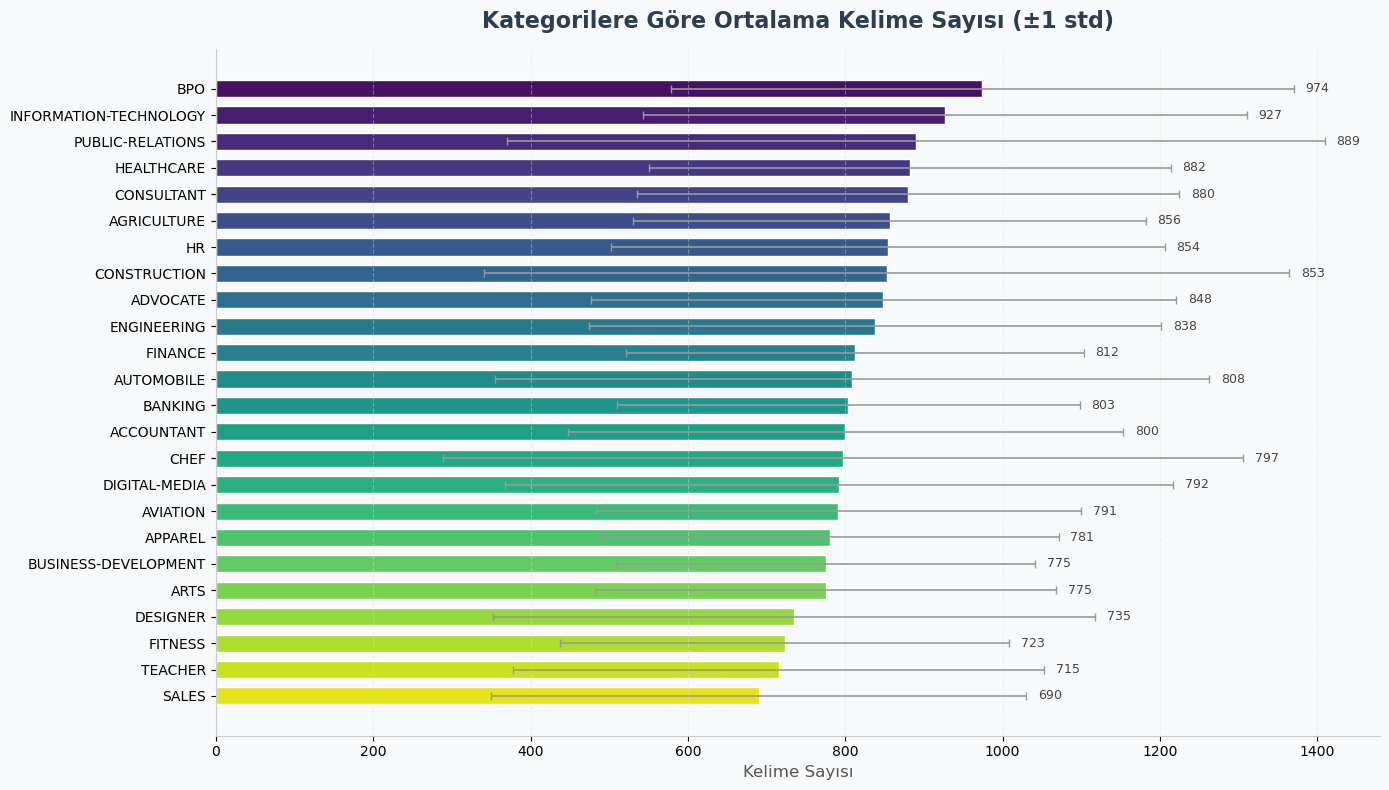

In [29]:
# ── Kategorilere göre ortalama kelime sayısı ─────────────────────────────────
wc_cat = (
    df.groupby('Category')['word_count']
    .agg(['mean', 'std', 'median'])
    .sort_values('mean', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(BG_COLOR)

colors_wc = sns.color_palette(PALETTE, n_colors=len(wc_cat))
bars = ax.barh(wc_cat['Category'], wc_cat['mean'], xerr=wc_cat['std'],
               color=colors_wc, edgecolor='white', height=0.65,
               error_kw={'ecolor': '#999', 'capsize': 3, 'lw': 1.2})

for bar, (_, row) in zip(bars, wc_cat.iterrows()):
    ax.text(bar.get_width() + row['std'] + 15,
            bar.get_y() + bar.get_height() / 2,
            f"{row['mean']:.0f}",
            va='center', fontsize=9, color='#444')

ax.set_title('Kategorilere Göre Ortalama Kelime Sayısı (±1 std)', **FONT_TITLE, pad=15)
ax.set_xlabel('Kelime Sayısı', **FONT_LABEL)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('../visuals/07_kategori_kelime_sayisi.png', dpi=200, bbox_inches='tight')
plt.show()

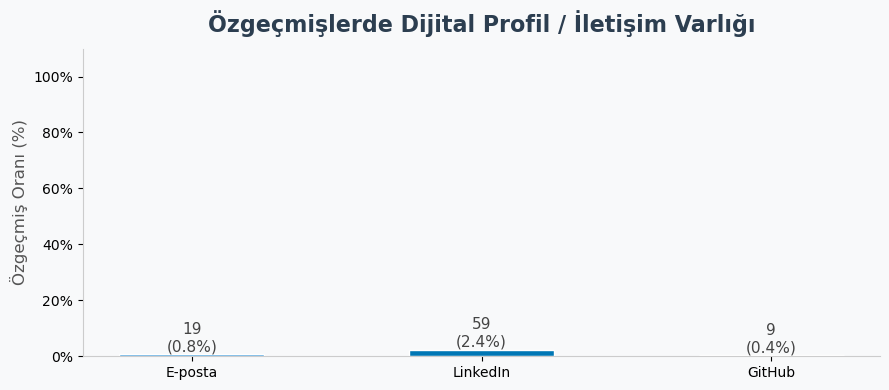

In [30]:
# ── Profil varlığı (e-mail, LinkedIn, GitHub) ─────────────────────────────────
profile_cols  = ['has_email', 'has_linkedin', 'has_github']
profile_labels = ['E-posta', 'LinkedIn', 'GitHub']
profile_vals   = [df[c].sum() for c in profile_cols]
profile_pct    = [v / len(df) * 100 for v in profile_vals]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(BG_COLOR)

bar_colors = ['#3498DB', '#0077B5', '#333333']
bars = ax.bar(profile_labels, profile_pct, color=bar_colors,
              edgecolor='white', width=0.5)
for bar, val, pct in zip(bars, profile_vals, profile_pct):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, color='#444')

ax.set_ylim(0, 110)
ax.set_title('Özgeçmişlerde Dijital Profil / İletişim Varlığı', **FONT_TITLE, pad=12)
ax.set_ylabel('Özgeçmiş Oranı (%)', **FONT_LABEL)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../visuals/08_dijital_profil.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 8. Kelime Bulutu & Frekans Analizi <a id='8'></a>

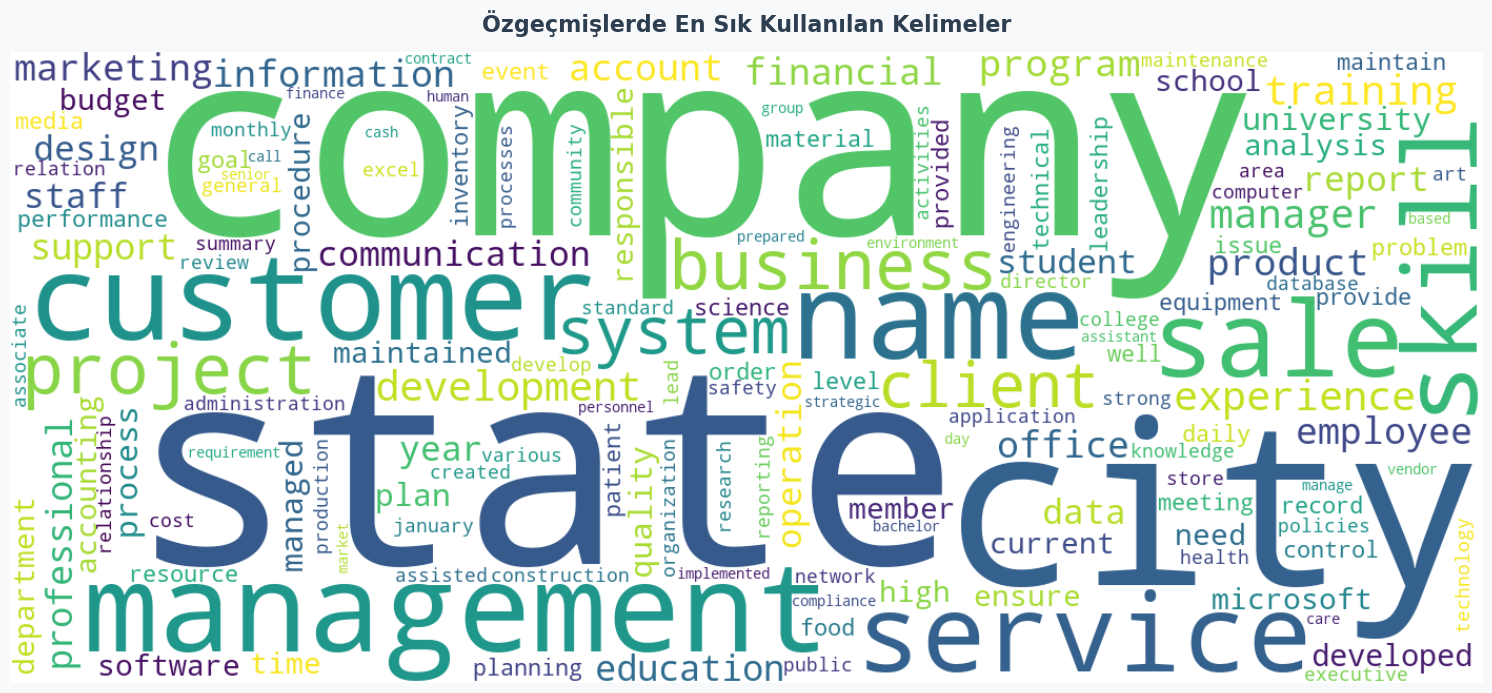

In [31]:
# ── Durdurma kelimeleri (stop words) ─────────────────────────────────────────
STOP_WORDS = {
    'the', 'and', 'to', 'of', 'a', 'in', 'for', 'is', 'on', 'with',
    'as', 'by', 'at', 'an', 'be', 'from', 'or', 'are', 'was', 'i',
    'my', 'me', 'we', 'it', 'this', 'that', 'have', 'has', 'had',
    'been', 'will', 'not', 'but', 'all', 'can', 'more', 'also', 'may',
    'used', 'using', 'work', 'worked', 'working', 'including', 'such',
    'their', 'they', 'our', 'were', 'which', 'into', 'over', 'other',
    'new', 'up', 'he', 'his', 'her', 'she', 'its', 'team', 'within',
    'across', 'through', 'under', 'about', 'between', 'while', 'during',
}

# ── Tüm metni temizle & birleştir ────────────────────────────────────────────
all_text = ' '.join(df['Resume_str'].astype(str))
all_text_clean = re.sub(r'[^\w\s]', ' ', all_text).lower()

words = [w for w in all_text_clean.split()
         if w not in STOP_WORDS and len(w) > 2]

# ── Kelime bulutu ─────────────────────────────────────────────────────────────
wc = WordCloud(
    width=1400, height=600,
    background_color='white',
    colormap='viridis',
    max_words=150,
    stopwords=STOP_WORDS,
    collocations=False,
).generate(' '.join(words))

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Özgeçmişlerde En Sık Kullanılan Kelimeler', **FONT_TITLE, pad=15)

plt.tight_layout()
plt.savefig('../visuals/09_kelime_bulutu.png', dpi=200, bbox_inches='tight')
plt.show()

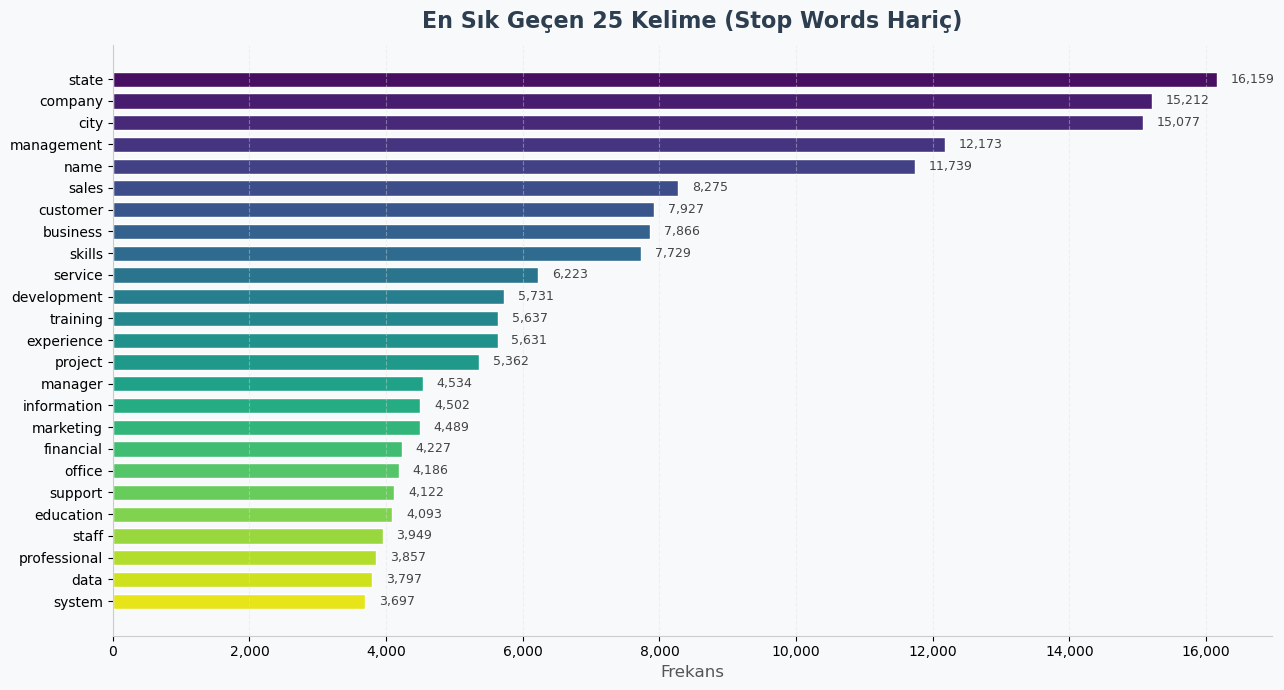

In [32]:
# ── Top-25 kelime frekans grafiği ────────────────────────────────────────────
top_words = Counter(words).most_common(25)
tw_df     = pd.DataFrame(top_words, columns=['word', 'freq'])

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG_COLOR)

colors_tw = sns.color_palette(PALETTE, n_colors=25)
bars = ax.barh(tw_df['word'][::-1], tw_df['freq'][::-1],
               color=colors_tw[::-1], edgecolor='white', height=0.7)

for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9, color='#444')

ax.set_title('En Sık Geçen 25 Kelime (Stop Words Hariç)', **FONT_TITLE, pad=12)
ax.set_xlabel('Frekans', **FONT_LABEL)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('../visuals/10_kelime_frekansi.png', dpi=200, bbox_inches='tight')
plt.show()

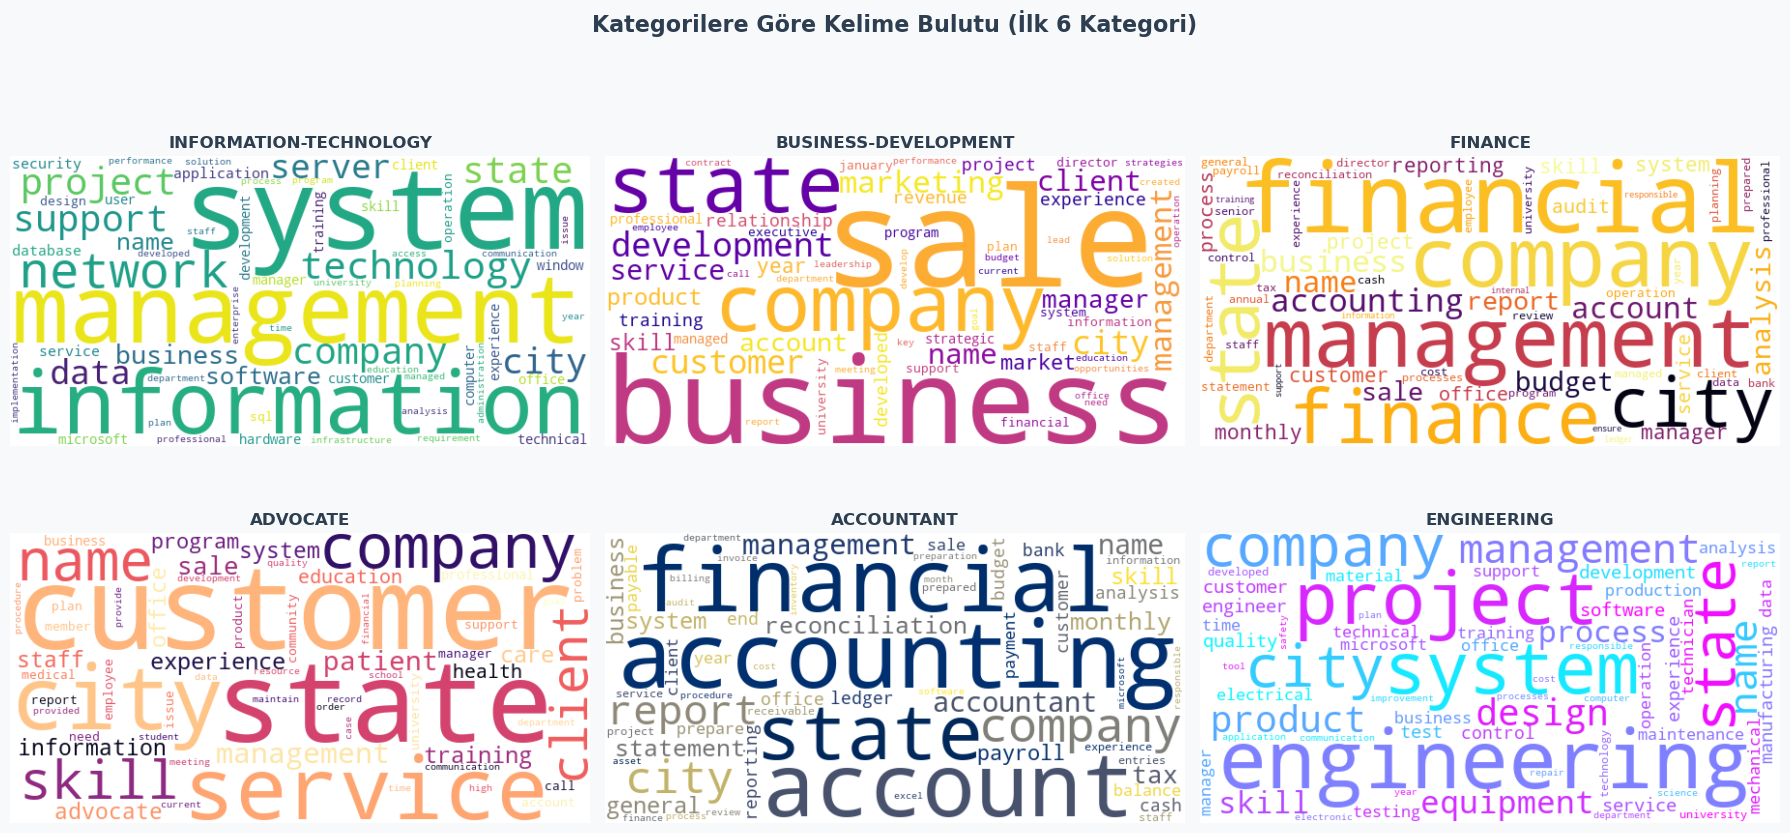

In [33]:
# ── Kategorilere göre ayrı kelime bulutu (ilk 6 kategori) ────────────────────
top6_cats = df['Category'].value_counts().index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Kategorilere Göre Kelime Bulutu (İlk 6 Kategori)', **FONT_TITLE, y=1.01)

cmaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis', 'cool']

for ax, cat, cmap_name in zip(axes.flatten(), top6_cats, cmaps):
    cat_text = ' '.join(df[df['Category'] == cat]['Resume_str'].astype(str))
    cat_clean = re.sub(r'[^\w\s]', ' ', cat_text).lower()
    cat_words = [w for w in cat_clean.split() if w not in STOP_WORDS and len(w) > 2]

    wc_cat = WordCloud(width=600, height=300, background_color='white',
                       colormap=cmap_name, max_words=60,
                       stopwords=STOP_WORDS, collocations=False).generate(' '.join(cat_words))
    ax.imshow(wc_cat, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(cat, fontsize=12, fontweight='bold', color=ACCENT, pad=6)

plt.tight_layout()
plt.savefig('../visuals/11_kategori_kelime_bulutu.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 9. Kategori × Deneyim İlişkisi <a id='9'></a>

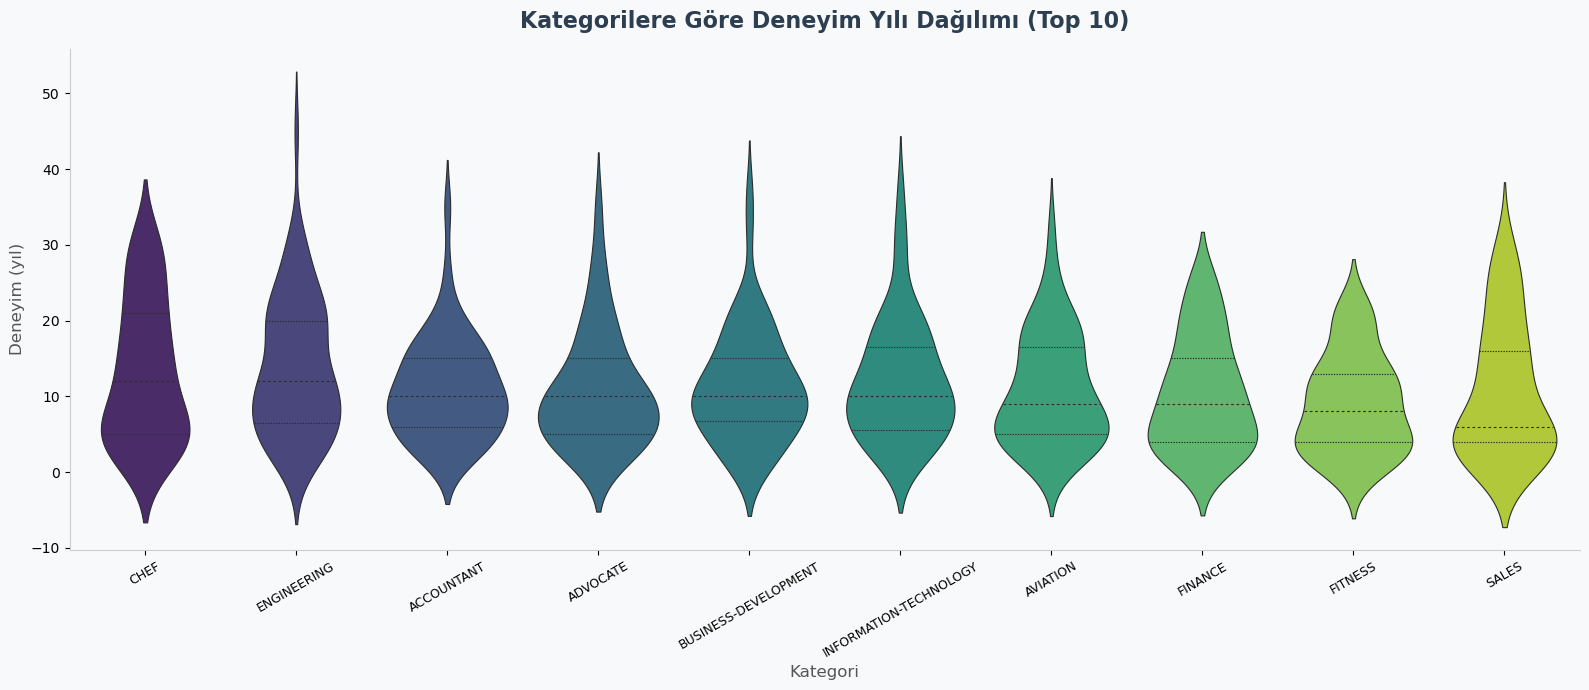

In [34]:
# ── Violin plot — kategorilere göre deneyim dağılımı ─────────────────────────
top10_cats = df['Category'].value_counts().index[:10].tolist()
violin_df  = exp_df[exp_df['Category'].isin(top10_cats)].copy()

# Kategori medyanına göre sırala
order_violin = (
    violin_df.groupby('Category')['experience']
    .median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG_COLOR)

sns.violinplot(
    data=violin_df, x='Category', y='experience',
    order=order_violin, palette=PALETTE,
    inner='quartile', density_norm='count',
    ax=ax, linewidth=0.8,
)
ax.set_title('Kategorilere Göre Deneyim Yılı Dağılımı (Top 10)', **FONT_TITLE, pad=15)
ax.set_xlabel('Kategori', **FONT_LABEL)
ax.set_ylabel('Deneyim (yıl)', **FONT_LABEL)
ax.tick_params(axis='x', rotation=30, labelsize=9)

plt.tight_layout()
plt.savefig('../visuals/12_violin_deneyim.png', dpi=200, bbox_inches='tight')
plt.show()

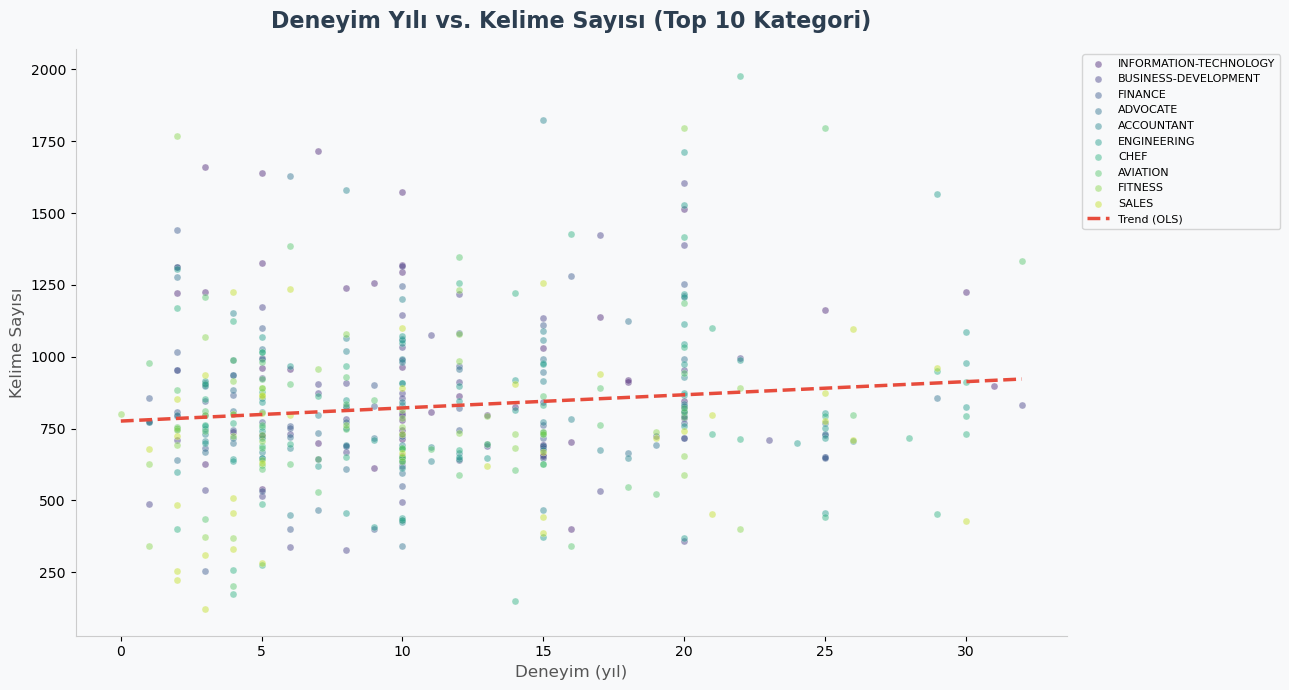

In [35]:
# ── Scatter: kelime sayısı vs. deneyim yılı (renkli kategori) ────────────────
scatter_df = exp_df[exp_df['Category'].isin(top10_cats)].copy()
scatter_df = scatter_df[
    (scatter_df['word_count'] < scatter_df['word_count'].quantile(0.99)) &
    (scatter_df['experience'] < 35)
]

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG_COLOR)

palette_scat = dict(zip(top10_cats, sns.color_palette(PALETTE, n_colors=10)))

for cat in top10_cats:
    sub = scatter_df[scatter_df['Category'] == cat]
    ax.scatter(sub['experience'], sub['word_count'],
               color=palette_scat[cat], alpha=0.45, s=25,
               edgecolors='white', linewidths=0.3, label=cat)

# Trend çizgisi (tüm veri)
z = np.polyfit(scatter_df['experience'], scatter_df['word_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['experience'].min(), scatter_df['experience'].max(), 100)
ax.plot(x_line, p(x_line), color=HIGHLIGHT, lw=2.5, linestyle='--', label='Trend (OLS)')

ax.set_title('Deneyim Yılı vs. Kelime Sayısı (Top 10 Kategori)', **FONT_TITLE, pad=15)
ax.set_xlabel('Deneyim (yıl)', **FONT_LABEL)
ax.set_ylabel('Kelime Sayısı', **FONT_LABEL)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=1)

plt.tight_layout()
plt.savefig('../visuals/13_scatter_deneyim_kelime.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 10. Korelasyon & Özet Dashboard <a id='10'></a>

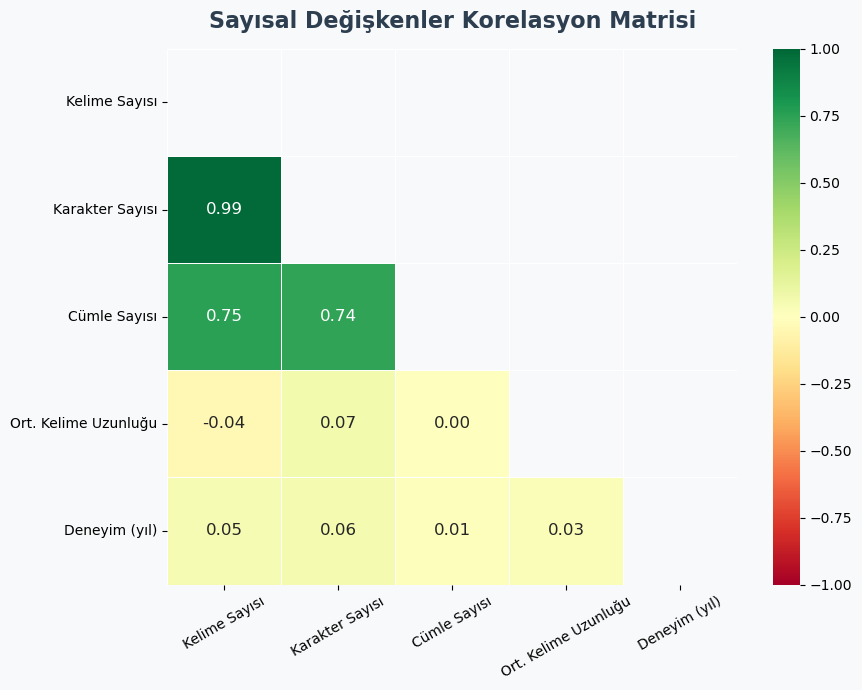

In [36]:
# ── Korelasyon ısı haritası ────────────────────────────────────────────────────
num_cols = ['word_count', 'char_count', 'sentence_count', 'avg_word_length', 'experience']
corr_df  = df[num_cols].dropna().corr().round(2)

labels_tr = {
    'word_count':      'Kelime Sayısı',
    'char_count':      'Karakter Sayısı',
    'sentence_count':  'Cümle Sayısı',
    'avg_word_length': 'Ort. Kelime Uzunluğu',
    'experience':      'Deneyim (yıl)',
}
corr_df.rename(index=labels_tr, columns=labels_tr, inplace=True)

mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG_COLOR)

sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 12},
)
ax.set_title('Sayısal Değişkenler Korelasyon Matrisi', **FONT_TITLE, pad=15)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('../visuals/14_korelasyon.png', dpi=200, bbox_inches='tight')
plt.show()

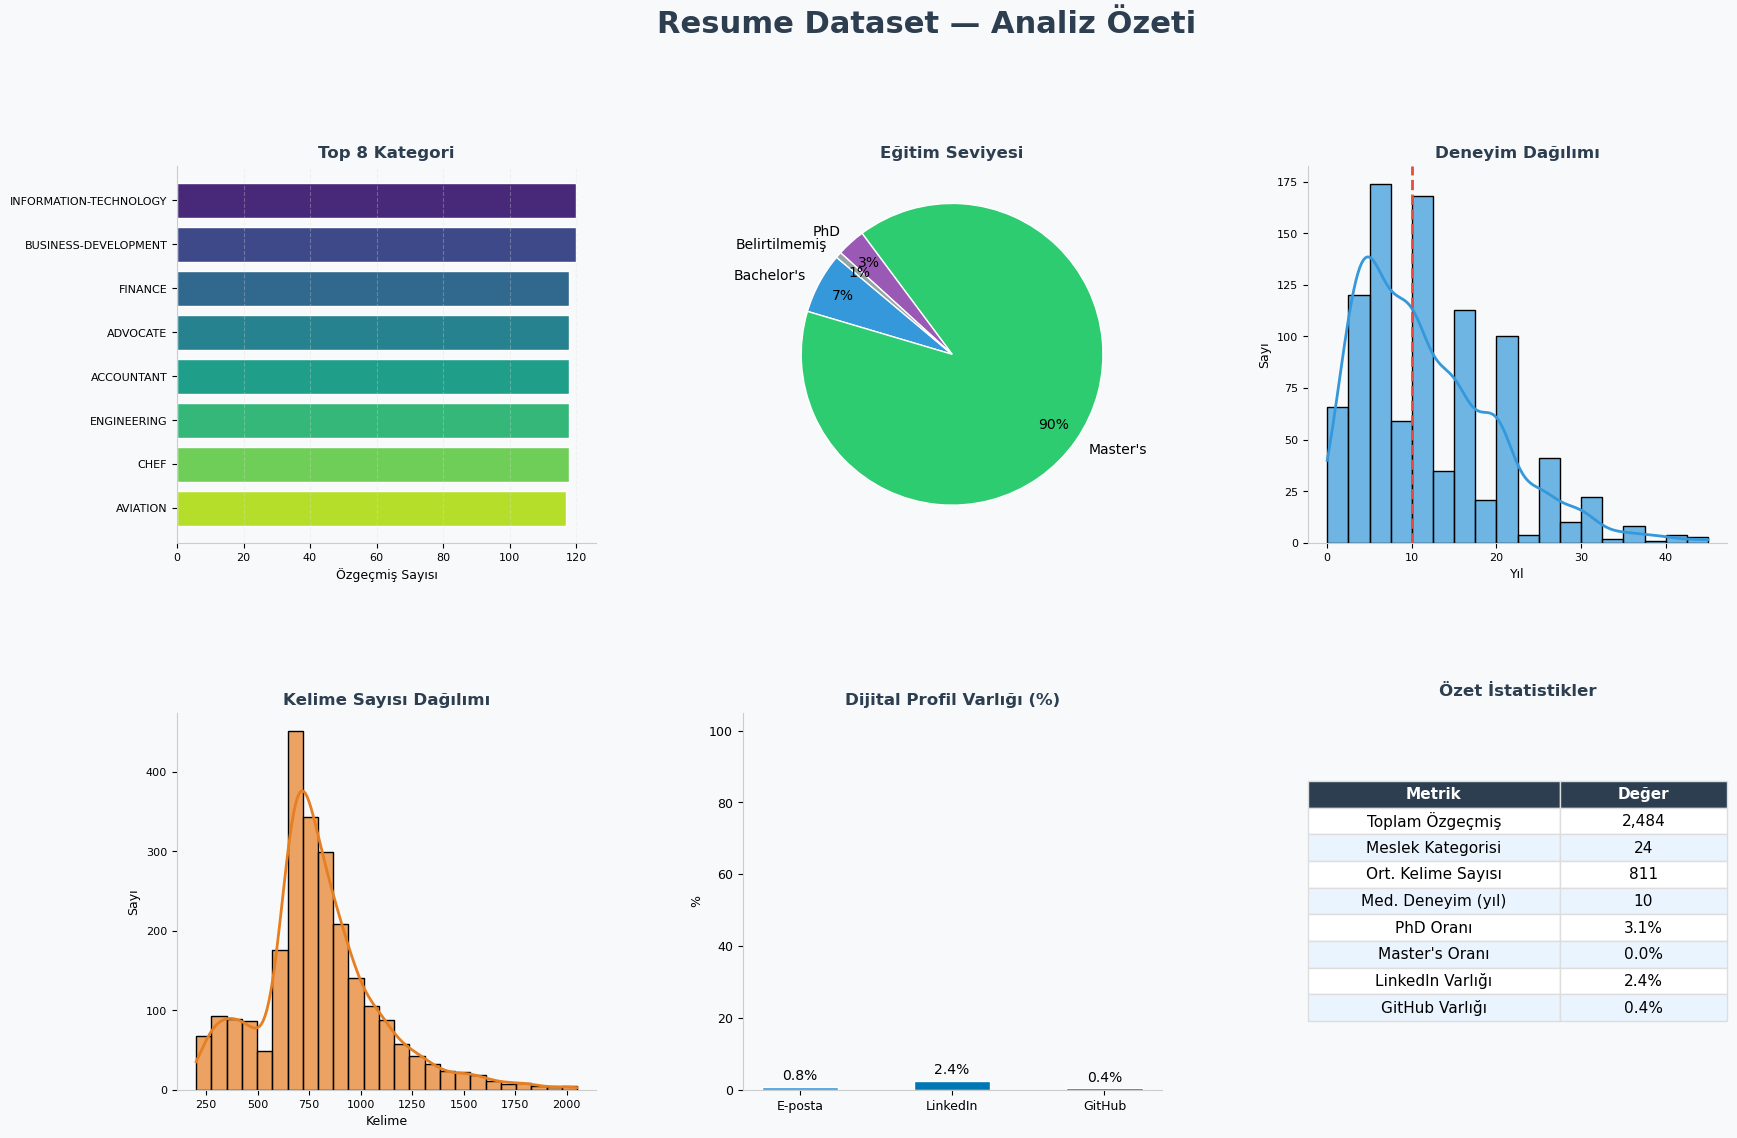

Tüm görseller ../visuals/ klasörüne kaydedildi.


In [43]:
# ── Özet dashboard ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Resume Dataset — Analiz Özeti', fontsize=22, fontweight='bold',
             color=ACCENT, y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── A: Kategori dağılımı (sol üst) ───────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
top8 = df['Category'].value_counts().head(8)
colors_a = sns.color_palette(PALETTE, n_colors=8)
ax_a.barh(top8.index, top8.values, color=colors_a, edgecolor='white')
ax_a.invert_yaxis()
ax_a.set_title('Top 8 Kategori', fontsize=12, fontweight='bold', color=ACCENT)
ax_a.set_xlabel('Özgeçmiş Sayısı', fontsize=9)
ax_a.tick_params(labelsize=8)
ax_a.grid(axis='x', alpha=0.3)

# ── B: Eğitim pasta (orta üst) ───────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
edu_vals = df['education_level'].value_counts().reindex(edu_order).fillna(0)
ax_b.pie(edu_vals, labels=edu_order, autopct='%1.0f%%',
         colors=['#3498DB', '#2ECC71', '#9B59B6', '#95A5A6'],
         wedgeprops={'edgecolor': 'white'}, pctdistance=0.82,
         startangle=140)
ax_b.set_title('Eğitim Seviyesi', fontsize=12, fontweight='bold', color=ACCENT)

# ── C: Deneyim hist (sağ üst) ────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
sns.histplot(exp_df['experience'], bins=18, kde=True, ax=ax_c,
             color='#3498DB', alpha=0.7, line_kws={'lw': 2, 'color': ACCENT})
ax_c.axvline(exp_df['experience'].median(), color=HIGHLIGHT, lw=2, linestyle='--')
ax_c.set_title('Deneyim Dağılımı', fontsize=12, fontweight='bold', color=ACCENT)
ax_c.set_xlabel('Yıl', fontsize=9)
ax_c.set_ylabel('Sayı', fontsize=9)
ax_c.tick_params(labelsize=8)

# ── D: Kelime sayısı hist (sol alt) ──────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0])
q1_wc, q3_wc = df['word_count'].quantile([.01, .99])
wc_clean = df[(df['word_count'] >= q1_wc) & (df['word_count'] <= q3_wc)]['word_count']
sns.histplot(wc_clean, bins=25, kde=True, ax=ax_d,
             color='#E67E22', alpha=0.7, line_kws={'lw': 2, 'color': ACCENT})
ax_d.set_title('Kelime Sayısı Dağılımı', fontsize=12, fontweight='bold', color=ACCENT)
ax_d.set_xlabel('Kelime', fontsize=9)
ax_d.set_ylabel('Sayı', fontsize=9)
ax_d.tick_params(labelsize=8)

# ── E: Dijital profil bar (orta alt) ─────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
ax_e.bar(['E-posta', 'LinkedIn', 'GitHub'], profile_pct,
         color=['#3498DB', '#0077B5', '#333'], edgecolor='white', width=0.5)
ax_e.set_ylim(0, 105)
ax_e.set_title('Dijital Profil Varlığı (%)', fontsize=12, fontweight='bold', color=ACCENT)
ax_e.set_ylabel('%', fontsize=9)
for i, pct in enumerate(profile_pct):
    ax_e.text(i, pct + 2, f'{pct:.1f}%', ha='center', fontsize=10)
ax_e.tick_params(labelsize=9)

# ── F: İstatistik tablosu (sağ alt) ──────────────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
ax_f.axis('off')
summary_data = [
    ['Toplam Özgeçmiş',      f"{len(df):,}"],
    ['Meslek Kategorisi',    str(df['Category'].nunique())],
    ['Ort. Kelime Sayısı',   f"{df['word_count'].mean():.0f}"],
    ['Med. Deneyim (yıl)',   f"{exp_df['experience'].median():.0f}"],
    ['PhD Oranı',            f"{(df['education_level']=='PhD').mean():.1%}"],
    ["Master's Oranı",       f"{(df['education_level'] == 'Master').mean():.1%}"],
    ['LinkedIn Varlığı',     f"{df['has_linkedin'].mean():.1%}"],
    ['GitHub Varlığı',       f"{df['has_github'].mean():.1%}"],
]
tbl = ax_f.table(
    cellText=summary_data,
    colLabels=['Metrik', 'Değer'],
    cellLoc='center', loc='center',
    colWidths=[0.6, 0.4],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#DDDDDD')
    if r == 0:
        cell.set_facecolor(ACCENT)
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF4FF')
    else:
        cell.set_facecolor('white')
ax_f.set_title('Özet İstatistikler', fontsize=12, fontweight='bold', color=ACCENT, pad=12)

plt.savefig('../visuals/15_ozet_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()
print('Tüm görseller ../visuals/ klasörüne kaydedildi.')